# PROJETO 2 ANADI - E-REDES

In [4]:
# TODOS OS IMPORTS SÃO FEITOS AQUI PARA MANTER SIMPLICIDADE
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import scipy.stats as stats
from scipy.stats import f_oneway, shapiro
import seaborn as sns
from sklearn.model_selection import KFold, cross_val_score, learning_curve
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC, LinearSVR
from sklearn.neural_network import MLPRegressor, MLPClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, accuracy_score, precision_score, recall_score, f1_score, root_mean_squared_error
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

In [5]:
ptd_df = pd.read_excel("./data/PTD_level_dataset.xlsx")

#### Helpers

In [6]:
def print_table(headers, rows, align=None, float_fmt=".4f", title=None):
    """
    Print formatted text tables.
    """

    # Infer alignment if not provided
    if align is None:
        align = [];
        for col in zip(*rows):
            if all(isinstance(v, (int, float)) for v in col):
                align.append(">");
            else:
                align.append("<");

    # Format values
    formatted_rows = [];
    for row in rows:
        formatted = [];
        for val in row:
            if isinstance(val, float):
                formatted.append(f"{val:{float_fmt}}");
            else:
                formatted.append(str(val));
        formatted_rows.append(formatted);

    # Compute column widths
    widths = []
    for i, h in enumerate(headers):
        col_values = [r[i] for r in formatted_rows];
        widths.append(max(len(h), *(len(v) for v in col_values)));

    if title:
        print(f"\n{title}");

    # Header
    header_line = "  " + " ".join(
        f"{h:{align[i]}{widths[i]}}" for i, h in enumerate(headers)
    )
    print(header_line);

    # Separator
    sep_line = "  " + " ".join("─" * w for w in widths);
    print(sep_line);

    # Rows
    for row in formatted_rows:
        print(
            "  " + " ".join(
                f"{row[i]:{align[i]}{widths[i]}}"
                for i in range(len(headers))
            )
        );

## 4.1 - Análise Exploratória de Dados

In [7]:
print(f"Número de registos (PTDs): {ptd_df.shape[0]}");
print(f"Número de variáveis: {ptd_df.shape[1]}");

print("\nTipo de dados:");
print(ptd_df.dtypes)

print("\nValores omissos:");
missing_count = ptd_df.isnull().sum();
missing_pct = (missing_count / len(ptd_df) * 100);
missing_df = pd.DataFrame({
    'Variável': missing_count.index,
    'Omissos (n)': missing_count.values,
    'Omissos (%)': missing_pct.values
});

print(missing_df[missing_df['Omissos (n)'] > 0]);

print("\nResumo estatístico: ");
print(ptd_df.describe())

Número de registos (PTDs): 72027
Número de variáveis: 32

Tipo de dados:
Distrito                      object
Concelho                      object
CodDistritoConcelho            int64
Código de Instalação          object
Coordenadas Geográficas       object
Potência instalada [kVA]       int64
Tipo Construtivo              object
Cap_PTD_kVA                    int64
Pot_Contratada_kVA           float64
N_Clientes                     int64
Pot_Geracao_kW               float64
N_Clientes_Produtores          int64
P_IP_Total                   float64
P_IP_Inef                    float64
Rate_Ineficiencia            float64
LED_Ratio                    float64
N_Luminarias                   int64
N_Lampadas                     int64
N_PTDs_Concelho                int64
PVE_PTD                      float64
D_PTD                        float64
IP_per_PTD                   float64
IP_Inef_per_PTD              float64
Ganho_LED_PTD                float64
D_PTD_LED                    float64
Ca

### 4.1.2 - Análise de Distribuições

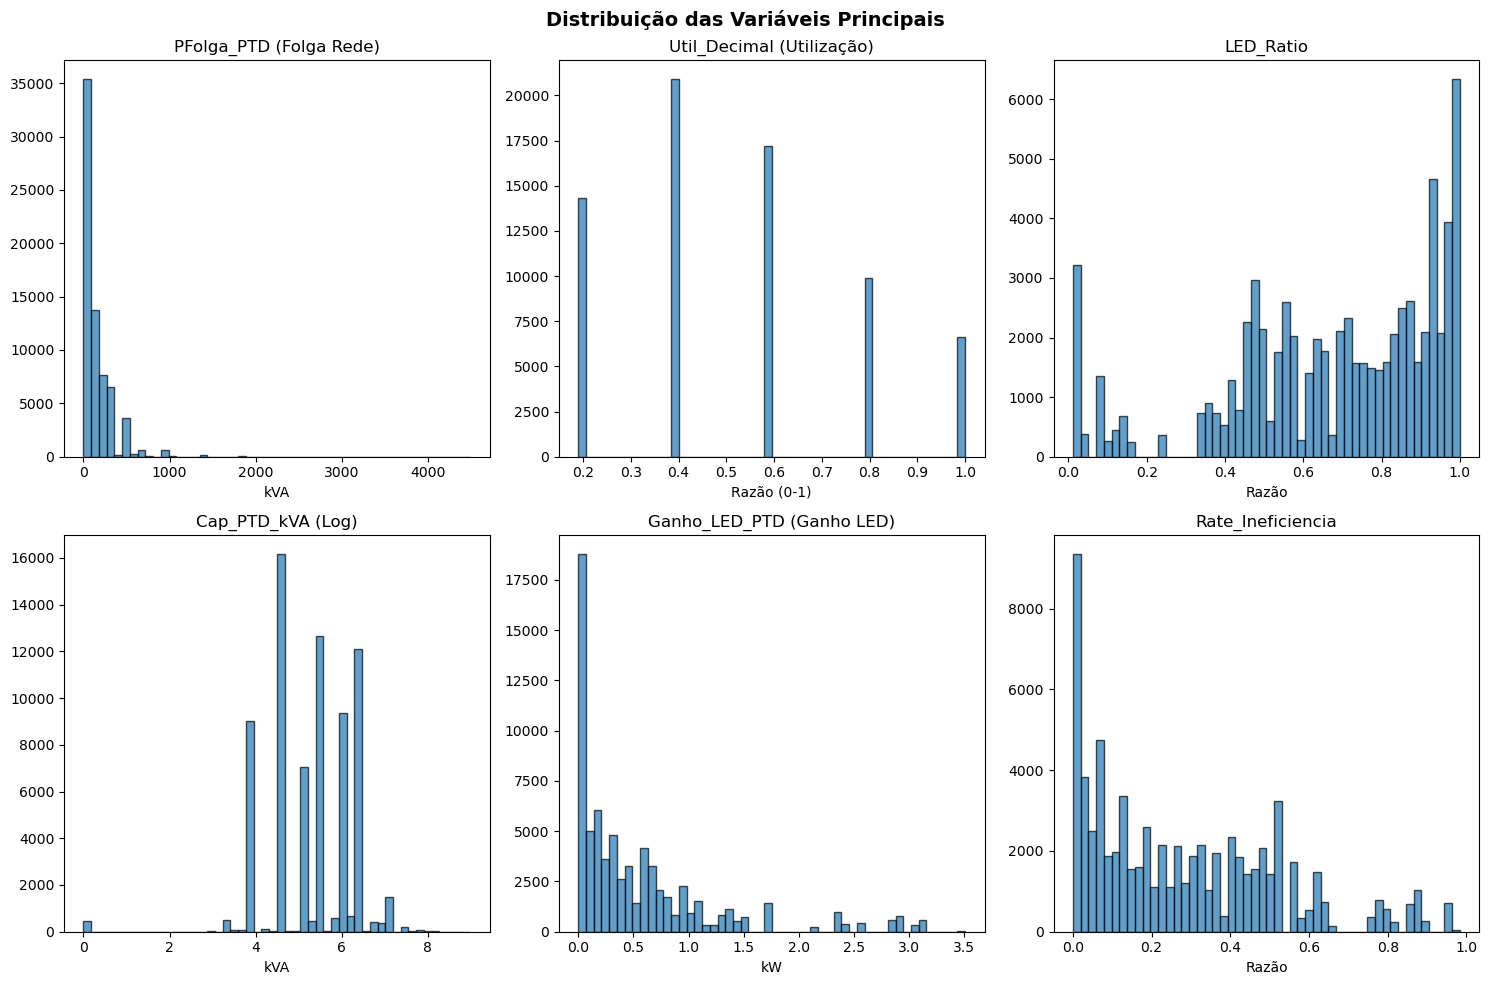

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10));
fig.suptitle("Distribuição das Variáveis Principais", fontsize=14, fontweight='bold');

# Distribuição de PFolga_PTD
axes[0, 0].hist(ptd_df['PFolga_PTD'].dropna(), bins=50, edgecolor='black', alpha=0.7);
axes[0, 0].set_title('PFolga_PTD (Folga Rede)');
axes[0, 0].set_xlabel('kVA');

# Distribuição de Util_Decimal
axes[0, 1].hist(ptd_df['Util_Decimal'].dropna(), bins=50, edgecolor='black', alpha=0.7);
axes[0, 1].set_title('Util_Decimal (Utilização)');
axes[0, 1].set_xlabel('Razão (0-1)');

# Distribuição de LED_Ratio
axes[0, 2].hist(ptd_df['LED_Ratio'].dropna(), bins=50, edgecolor='black', alpha=0.7);
axes[0, 2].set_title('LED_Ratio');
axes[0, 2].set_xlabel('Razão');

# Distribuição de Cap_PTD_kVA
axes[1, 0].hist(np.log1p(ptd_df['Cap_PTD_kVA'].dropna()), bins=50, edgecolor='black', alpha=0.7);
axes[1, 0].set_title('Cap_PTD_kVA (Log)');
axes[1, 0].set_xlabel('kVA');

# Distribuição de Ganho_LED_PTD
axes[1, 1].hist(ptd_df['Ganho_LED_PTD'].dropna(), bins=50, edgecolor='black', alpha=0.7);
axes[1, 1].set_title('Ganho_LED_PTD (Ganho LED)');
axes[1, 1].set_xlabel('kW');

# Distribuição de Rate_Ineficiencia
axes[1, 2].hist(ptd_df['Rate_Ineficiencia'].dropna(), bins=50, edgecolor='black', alpha=0.7);
axes[1, 2].set_title('Rate_Ineficiencia');
axes[1, 2].set_xlabel('Razão');

plt.tight_layout();
plt.show();

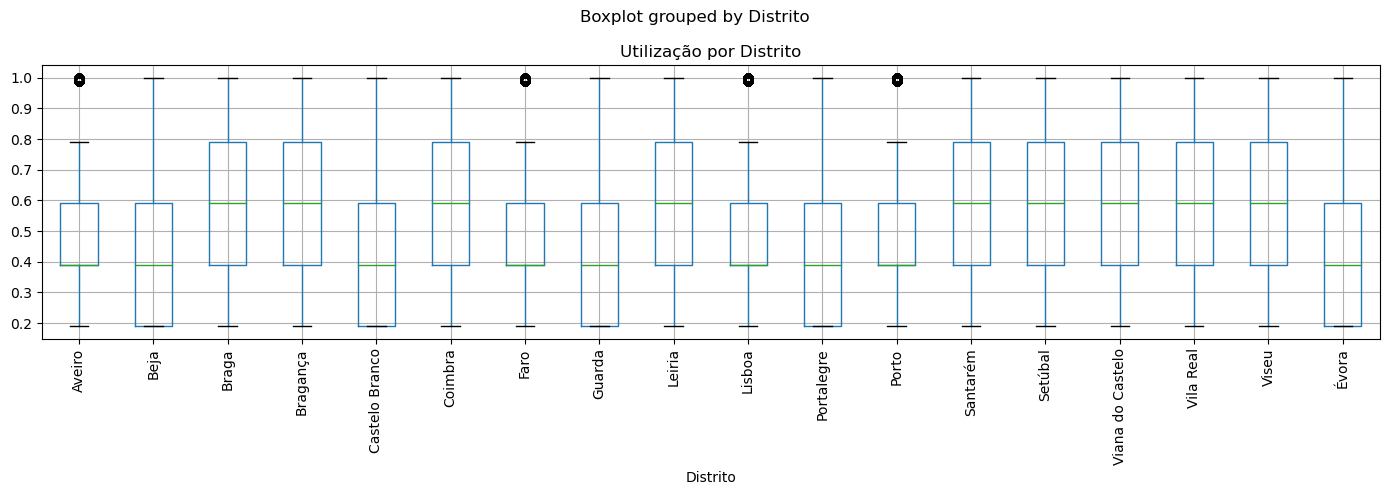

In [9]:
fig, ax = plt.subplots(figsize=(14, 5));
ptd_df.boxplot(column='Util_Decimal', by='Distrito', ax=ax, rot=90);
ax.set_title('Utilização por Distrito');
plt.tight_layout();
plt.show();

### 4.1.3 - Pré-processamento dos dados

#### Selecção de variáveis relevantes

In [10]:
# Removidas:
#   - Identificadores sem poder preditivo: Código de Instalação, CodDistritoConcelho
#   - Redundantes: Cap_PTD_kVA == Potência instalada [kVA] (duplicado)
#   - Coordenadas Geográficas: texto livre, sem geocoding                                 <--- Isto pode ser util para fazer coisas engraçadas
#   - Nível de Utilização [%]: versão string de Util_Decimal (redundante)
#   - Pot_Geracao_kW / Geracao_per_Cliente: 97% omissos                                   <--- De certeza que queremos isto?
#   - N_Clientes_Produtores: near-constant (75th pct == min == 20)
#   - Clientes_Produtores_Ratio: derivado de N_Clientes_Produtores
#   - Pot_Contratada_kVA / PContratada_per_Cliente: 29% omissos                           <--- ??
#   - N_PTDs_Concelho / IP_per_PTD / IP_Inef_per_PTD: agregados de concelho,
#     não propriedades do PTD individual

cols_to_drop = [
    'Código de Instalação',
    'CodDistritoConcelho',
    'Coordenadas Geográficas',
    'Nível de Utilização [%]',
    'Cap_PTD_kVA',
    'Pot_Geracao_kW',
    'Geracao_per_Cliente',
    'N_Clientes_Produtores',
    'Clientes_Produtores_Ratio',
    'Pot_Contratada_kVA',
    'PContratada_per_Cliente',
    'N_PTDs_Concelho',
    'IP_per_PTD',
    'IP_Inef_per_PTD',
];

df = ptd_df.drop(columns=cols_to_drop);
print(f"Variáveis após seleção: {df.shape[1]} (removidas {len(cols_to_drop)})");
print(f"Variáveis mantidas: {df.columns.tolist()}");

Variáveis após seleção: 18 (removidas 14)
Variáveis mantidas: ['Distrito', 'Concelho', 'Potência instalada [kVA]', 'Tipo Construtivo', 'N_Clientes', 'P_IP_Total', 'P_IP_Inef', 'Rate_Ineficiencia', 'LED_Ratio', 'N_Luminarias', 'N_Lampadas', 'PVE_PTD', 'D_PTD', 'Ganho_LED_PTD', 'D_PTD_LED', 'Cap_per_Cliente', 'Util_Decimal', 'PFolga_PTD']


#### Tratamento de valores omissos

In [11]:
# D_PTD, D_PTD_LED, Util_Decimal, PFolga_PTD: ~4.25% omissos
# São variáveis target, não podem ser imputadas então removemos as linhas

print(f"\nRegistos antes de remover omissos nas targets: {len(df)}");
df = df.dropna(subset=['D_PTD', 'D_PTD_LED', 'Util_Decimal', 'PFolga_PTD']);
print(f"Registos após remoção: {len(df)} (removidos {72027 - len(df)}, {(72027 - len(df)) / 72027 * 100:.1f}%)");

remaining_missing = df.isnull().sum();
print(f"\nOmissos restantes:\n{remaining_missing[remaining_missing > 0]}");


Registos antes de remover omissos nas targets: 72027
Registos após remoção: 68963 (removidos 3064, 4.3%)

Omissos restantes:
Series([], dtype: int64)


#### Transformação de variáveis categóricas

In [12]:
# Tipo Construtivo: baixa cardinalidade → One-Hot Encoding
# Distrito: 18 categorias → Label Encoding
# Concelho: 278 categorias → Label Encoding (One-Hot criaria colunas excessivas)

print("\nVariáveis categóricas:");
print(f"\tDistrito:         {df['Distrito'].nunique()} categorias");
print(f"\tConcelho:         {df['Concelho'].nunique()} categorias");
print(f"\tTipo Construtivo: {df['Tipo Construtivo'].nunique()} categorias: {df['Tipo Construtivo'].unique()}");

le_distrito = LabelEncoder();
le_concelho = LabelEncoder();
df['Distrito_enc'] = le_distrito.fit_transform(df['Distrito']);
df['Concelho_enc'] = le_concelho.fit_transform(df['Concelho']);
df = pd.get_dummies(df, columns=['Tipo Construtivo'], prefix='TipoConst', drop_first=False);
df = df.drop(columns=['Distrito', 'Concelho']);

print(f"\nShape após encoding: {df.shape}");


Variáveis categóricas:
	Distrito:         18 categorias
	Concelho:         278 categorias
	Tipo Construtivo: 9 categorias: ['Cabine pré-fabricada' 'Cabine baixa integrada em edifício' 'Cabine alta'
 'Aéreo - AS' 'Aéreo - AI' 'Cabine baixa em edifício próprio'
 'Cabine subterrânea' 'Cabine metálica (monobloco)' 'Aéreo - A']

Shape após encoding: (68963, 26)


#### Variaveis target e features

In [13]:
# Derivada de Util_Decimal com base em quantis (33% e 66%) para garantir
# classes balanceadas, evitando problemas de desequilíbrio na classificação.
# Justificação: a distribuição de Util_Decimal não é uniforme; limiares fixos
# (ex: 0.4/0.75) gerariam classes muito desiguais, prejudicando os modelos.

q33 = df['Util_Decimal'].quantile(0.33);
q66 = df['Util_Decimal'].quantile(0.66);

df['utilizRede'] = pd.cut(
    df['Util_Decimal'],
    bins=[-np.inf, q33, q66, np.inf],
    labels=['baixo', 'medio', 'alto']
);

print(f"\nLimiares utilizRede (quantis): baixo < {q33:.3f} <= medio < {q66:.3f} <= alto");
print("\nDistribuição de utilizRede:");
print(df['utilizRede'].value_counts().sort_index());
print(df['utilizRede'].value_counts(normalize=True).sort_index());


Limiares utilizRede (quantis): baixo < 0.390 <= medio < 0.590 <= alto

Distribuição de utilizRede:
utilizRede
baixo    35230
medio    17175
alto     16558
Name: count, dtype: int64
utilizRede
baixo    0.510854
medio    0.249047
alto     0.240100
Name: proportion, dtype: float64


In [14]:
# Targets de regressão (variáveis calculadas na 1ª iteração per enunciado)
regression_targets = ['PFolga_PTD', 'Ganho_LED_PTD', 'D_PTD', 'Rate_Ineficiencia', 'PVE_PTD'];

# Target de classificação
classification_target = 'utilizRede';

# Excluídas das features para evitar data leakage:
#   - Todos os targets de regressão
#   - utilizRede e Util_Decimal (target de classificação e sua origem)
#   - D_PTD_LED: variante direta de D_PTD

exclude_from_features = regression_targets + [
    classification_target,
    'Util_Decimal',
    'D_PTD_LED',
];

feature_cols = [c for c in df.select_dtypes(include='number').columns
                if c not in exclude_from_features];

print(f"\nFeatures selecionadas ({len(feature_cols)}):");
for f in feature_cols:
    print(f"\t- {f}");


Features selecionadas (10):
	- Potência instalada [kVA]
	- N_Clientes
	- P_IP_Total
	- P_IP_Inef
	- LED_Ratio
	- N_Luminarias
	- N_Lampadas
	- Cap_per_Cliente
	- Distrito_enc
	- Concelho_enc


#### Normalização

In [15]:
# Necessário para KNN, SVM e Redes Neuronais (sensíveis à escala das features).
# Árvores de decisão não são afetadas mas a standardização não as prejudica.

X = df[feature_cols].copy()
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=feature_cols, index=df.index)

print(f"\nNormalização concluída. Shape de X_scaled: {X_scaled.shape}")
print("\nVerificação (médias ~= 0, std ~= 1):")
print(X_scaled.describe().loc[['mean', 'std']])


Normalização concluída. Shape de X_scaled: (68963, 10)

Verificação (médias ~= 0, std ~= 1):
      Potência instalada [kVA]    N_Clientes    P_IP_Total     P_IP_Inef  \
mean              4.615854e-17 -1.112751e-17  1.178691e-16  4.451002e-17   
std               1.000007e+00  1.000007e+00  1.000007e+00  1.000007e+00   

         LED_Ratio  N_Luminarias    N_Lampadas  Cap_per_Cliente  Distrito_enc  \
mean -7.583189e-17 -6.181947e-17 -2.802483e-17     1.322937e-16      0.000000   
std   1.000007e+00  1.000007e+00  1.000007e+00     1.000007e+00      1.000007   

      Concelho_enc  
mean -7.253485e-17  
std   1.000007e+00  


#### Cleanup

In [16]:
# Regressão: targets contínuos, sem transformação adicional
y_reg  = df['PFolga_PTD']; 

# Classificação: encoding ordinal de utilizRede para sklearn
le_utiliz = LabelEncoder();
y_clf = le_utiliz.fit_transform(df['utilizRede']);   # baixo=0, medio=1, alto=2
y_clf_encoded = y_clf;
print(f"\nClasses codificadas: {dict(zip(le_utiliz.classes_, le_utiliz.transform(le_utiliz.classes_)))}");

# Variáveis de suporte para análise posterior
selected_features_reg = feature_cols;
selected_features_clf = feature_cols;

X_reg_scaled = X_scaled;
X_clf_scaled = X_scaled;


Classes codificadas: {'alto': 0, 'baixo': 1, 'medio': 2}


In [17]:
print("Resultados pré-processamento")
print(f"\tRegistos finais: \t{len(df)}")
print(f"\tFeatures: \t\t{len(feature_cols)}")
print(f"\tTarget regressão: \tPFolga_PTD")
print(f"\tTarget classificação: \tutilizRede (baixo/medio/alto)")
print(f"\tOmissos em X_scaled: \t{X_scaled.isnull().sum().sum()}")
print(f"\tOmissos em y_reg: \t{y_reg.isnull().sum()}")
print(f"\tOmissos em y_clf: \t{pd.Series(y_clf).isnull().sum()}")

Resultados pré-processamento
	Registos finais: 	68963
	Features: 		10
	Target regressão: 	PFolga_PTD
	Target classificação: 	utilizRede (baixo/medio/alto)
	Omissos em X_scaled: 	0
	Omissos em y_reg: 	0
	Omissos em y_clf: 	0


## 4.2 Regressão

### 4.2.1 Crie um diagrama de correlação entre a variável PFolga_PTD e as restantes variáveis e interprete

Heatmap de correlação
PFolga_PTD                   1.000000
D_PTD                        1.000000
D_PTD_LED                    0.999979
Cap_PTD_kVA                  0.806477
Potência instalada [kVA]     0.806477
Cap_per_Cliente              0.632685
P_IP_Total                   0.147729
N_PTDs_Concelho              0.127164
PContratada_per_Cliente      0.108579
Pot_Contratada_kVA           0.087915
P_IP_Inef                    0.061536
IP_per_PTD                   0.055998
N_Clientes                   0.054174
CodDistritoConcelho          0.053210
Clientes_Produtores_Ratio    0.053142
N_Lampadas                   0.046996
N_Luminarias                 0.046492
Geracao_per_Cliente          0.033846
Ganho_LED_PTD                0.029368
IP_Inef_per_PTD              0.029368
Rate_Ineficiencia           -0.012273
Pot_Geracao_kW              -0.025849
N_Clientes_Produtores       -0.047034
LED_Ratio                   -0.054994
Util_Decimal                -0.832147
PVE_PTD                     

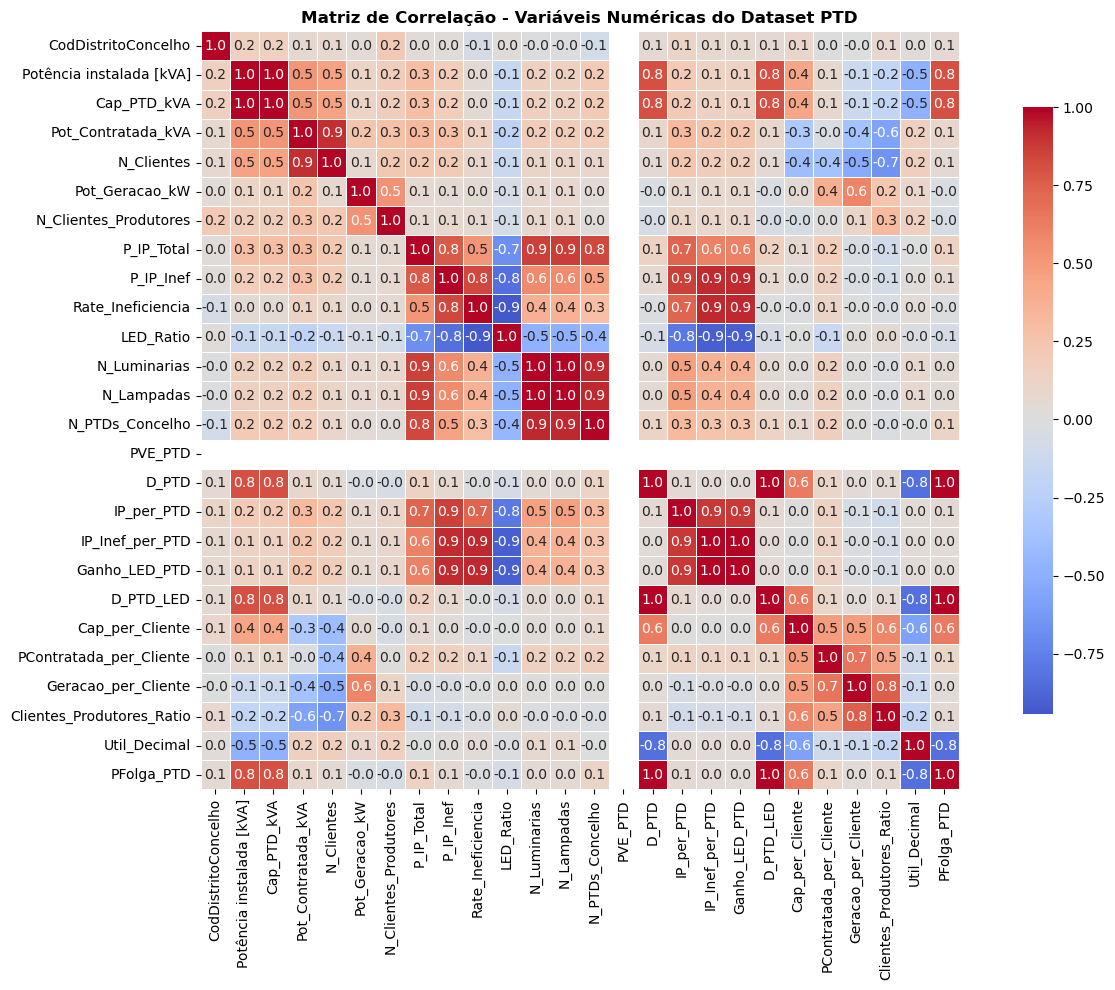

In [34]:
# Selecionar variáveis numéricas para correlação
numeric_cols = ptd_df.select_dtypes(include=[np.number]).columns;
numeric_df = ptd_df[numeric_cols].dropna();

# Calcular correlação com PFolga_PTD
correlation_with_target = numeric_df.corr()['PFolga_PTD'].sort_values(ascending=False);

print("Heatmap de correlação");
print(correlation_with_target);

fig, ax = plt.subplots(figsize=(14, 10));
corr_matrix = numeric_df.corr();
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax, fmt=".1f");
plt.title("Matriz de Correlação - Variáveis Numéricas do Dataset PTD", fontsize=12, fontweight='bold');
plt.tight_layout();
plt.show();

### 4.2.2 - Regrassão linear simples (K-Fold Cross Validation)

In [19]:
# Calculamos a correlação de todas as features com PFolga_PTD e escolhemos
# a de maior correlação absoluta — garante escolha objetiva e justificável.

correlations = X_scaled.corrwith(y_reg).abs().sort_values(ascending=False)
best_feature  = correlations.index[0]
best_corr     = correlations.iloc[0]

print(f"\nTop 5 correlações com PFolga_PTD:")
for feat, corr in correlations.head(5).items():
    marker = " foi selecionada" if feat == best_feature else ""
    print(f"  {feat:<35} r = {corr:.4f}{marker}")

print(f"{best_feature} tem a correlação linear mais forte com PFolga_PTD (|r| = {best_corr:.4f}), sendo a variável com maior poder explicativo individual para a regressão linear simples.")


Top 5 correlações com PFolga_PTD:
  Potência instalada [kVA]            r = 0.9159 foi selecionada
  Cap_per_Cliente                     r = 0.5996
  P_IP_Total                          r = 0.3884
  N_Lampadas                          r = 0.3585
  N_Luminarias                        r = 0.3575
Potência instalada [kVA] tem a correlação linear mais forte com PFolga_PTD (|r| = 0.9159), sendo a variável com maior poder explicativo individual para a regressão linear simples.


In [ ]:
# K-FOLD CROSS VALIDATION (k=5)
# TODO: Configurar n-splits
X_simple = X_scaled[[best_feature]]
y = y_reg.values

kf = KFold(n_splits=5, shuffle=True, random_state=42)

mae_scores, rmse_scores = [], []
coefs, intercepts = [], []
y_real_all, y_pred_all = [], []

for fold, (train_idx, test_idx) in enumerate(kf.split(X_simple), 1):
    X_train, X_test = X_simple.iloc[train_idx], X_simple.iloc[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae_scores.append(mean_absolute_error(y_test, y_pred))
    rmse_scores.append(root_mean_squared_error(y_test, y_pred))
    coefs.append(model.coef_[0])
    intercepts.append(model.intercept_)
    y_real_all.extend(y_test)
    y_pred_all.extend(y_pred)

# Modelo final: média dos coeficientes dos 5 folds
mean_coef = np.mean(coefs)
mean_intercept = np.mean(intercepts)
mean_mae = np.mean(mae_scores)
mean_rmse = np.mean(rmse_scores)
std_mae = np.std(mae_scores)
std_rmse = np.std(rmse_scores)

In [21]:
# Função linear resultante
print(f"\nPFolga_PTD = {mean_coef:.4f} * {best_feature} + {mean_intercept:.4f}")
print(f"\t(coeficientes: média dos 5 folds do K-Fold CV)")
print(f"\nInterpretação: por cada unidade de aumento em {best_feature}")
print(f"\t(escala standardizada), PFolga_PTD varia {mean_coef:.4f} kVA.")


PFolga_PTD = 171.0496 * Potência instalada [kVA] + 147.9832
	(coeficientes: média dos 5 folds do K-Fold CV)

Interpretação: por cada unidade de aumento em Potência instalada [kVA]
	(escala standardizada), PFolga_PTD varia 171.0496 kVA.


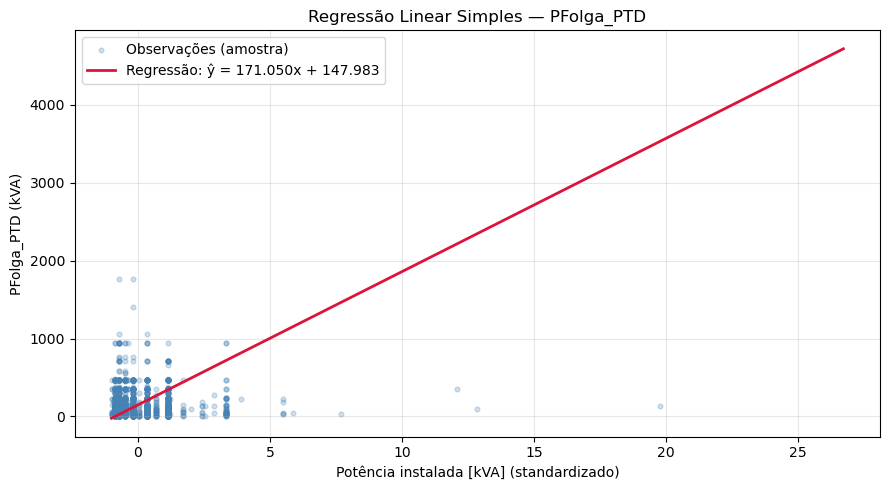

In [ ]:
# Diagrama de dispersão e reta de regressão
# Amostra para visualização (72k pontos saturaria o gráfico)

#TODO: ATENÇÃO CODIGO DE SAMPLES PRECISA DE CONFIGURAÇÃO
sample_n  = 2000
rng       = np.random.default_rng(42)
sample_idx = rng.choice(len(y_real_all), size=sample_n, replace=False)

x_sample  = np.array(X_simple[best_feature])[sample_idx] \
            if len(y_real_all) == len(X_simple) \
            else np.array(X_simple[best_feature].values)[sample_idx]

y_sample  = np.array(y_real_all)[sample_idx]

x_line    = np.linspace(X_simple[best_feature].min(), X_simple[best_feature].max(), 300)
y_line    = mean_coef * x_line + mean_intercept

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(x_sample, y_sample, alpha=0.25, s=12, color='steelblue', label='Observações (amostra)')
ax.plot(x_line, y_line, color='crimson', linewidth=2,
        label=f'Regressão: ŷ = {mean_coef:.3f}x + {mean_intercept:.3f}')
ax.set_xlabel(f'{best_feature} (standardizado)')
ax.set_ylabel('PFolga_PTD (kVA)')
ax.set_title('Regressão Linear Simples — PFolga_PTD')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
rows = [
    [i, mae, rmse]
    for i, (mae, rmse) in enumerate(zip(mae_scores, rmse_scores), 1)
]

rows += [
    ["Média", mean_mae, mean_rmse],
    ["Std", std_mae, std_rmse],
]

print_table(
    headers=["Fold", "MAE", "RMSE"],
    rows=rows,
    title="MAE e RMSE"
)

print("\nInterpretação:")
print(f"\tMAE  = {mean_mae:.2f} kVA: erro médio absoluto por PTD")
print(f"\tRMSE = {mean_rmse:.2f} kVA: penaliza mais os erros grandes")


MAE e RMSE
  Fold      MAE    RMSE
  ───── ─────── ───────
  1     50.8692 75.4987
  2     50.6930 74.6582
  3     51.1695 75.5031
  4     50.4508 74.5950
  5     50.5647 74.6071
  Média 50.7494 74.9724
  Std    0.2519  0.4320

Interpretação:
  MAE  = 50.75 kVA: erro médio absoluto por PTD
  RMSE = 74.97 kVA: penaliza mais os erros grandes


### 4.2.3 - Modelos de regressão (K-Fold Cross Validation)

In [ ]:
# TODO: Configurar n-splits
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# corre CV e devolve métricas + previsões concatenadas
def run_cv(model, X, y, kf):
    mae_scores, rmse_scores = [], []
    y_real_all, y_pred_all  = [], []

    for train_idx, test_idx in kf.split(X):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        mae_scores.append(mean_absolute_error(y_test, y_pred))
        rmse_scores.append(root_mean_squared_error(y_test, y_pred))
        y_real_all.extend(y_test)
        y_pred_all.extend(y_pred)

    return {
        'mae_mean': np.mean(mae_scores), 'mae_std': np.std(mae_scores),
        'rmse_mean': np.mean(rmse_scores), 'rmse_std': np.std(rmse_scores),
        'y_real': np.array(y_real_all), 'y_pred': np.array(y_pred_all),
        'mae_folds': mae_scores, 'rmse_folds': rmse_scores
    }

X = X_reg_scaled
y = y_reg.values
results_all = {}

In [ ]:
# Regressão linear múltipla

model_lr = LinearRegression()
res_lr   = run_cv(model_lr, X, y, kf)
results_all['Linear'] = res_lr

# Treinar no dataset completo para obter coeficientes finais
model_lr.fit(X, y)
coef_df = pd.DataFrame({
    'Feature':     selected_features_reg,
    'Coeficiente': model_lr.coef_
}).sort_values('Coeficiente', key=abs, ascending=False)

print(f"\nTop 10 coeficientes (valor absoluto):")
print(coef_df.head(10).to_string(index=False))

print(f"\nIntercepto: {model_lr.intercept_:.4f}")
print(f"\nMAE  = {res_lr['mae_mean']:.4f} +/- {res_lr['mae_std']:.4f}")
print(f"RMSE = {res_lr['rmse_mean']:.4f} +/- {res_lr['rmse_std']:.4f}")


Top 10 coeficientes (valor absoluto):
                 Feature  Coeficiente
              N_Lampadas  -251.328112
            N_Luminarias   237.573447
Potência instalada [kVA]   196.877626
              N_Clientes   -53.704141
              P_IP_Total    14.304770
               P_IP_Inef    -5.195123
            Concelho_enc     0.945135
         Cap_per_Cliente    -0.567904
            Distrito_enc    -0.556864
               LED_Ratio     0.404756

Intercepto: 147.9833

MAE  = 37.4910 ± 0.2554
RMSE = 57.2960 ± 0.3081



  MAE  = 36.3321 ± 0.3872
  RMSE = 59.3109 ± 0.7100


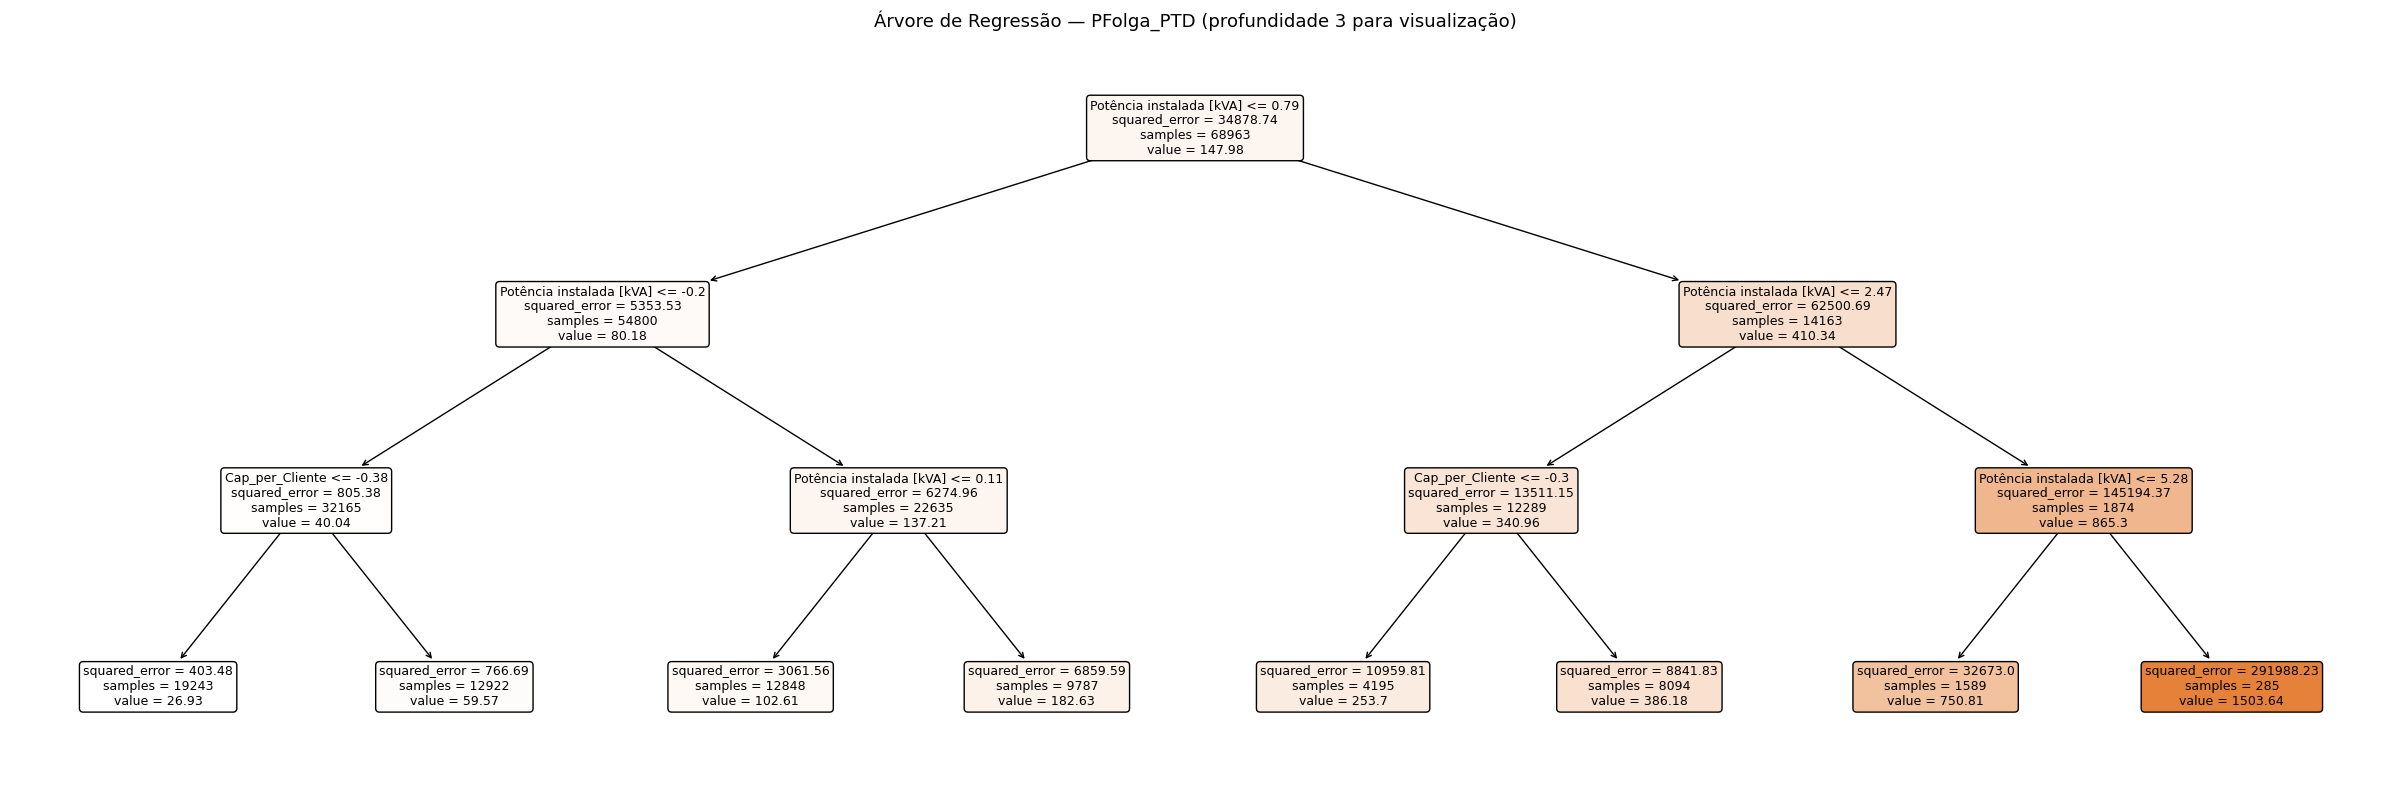

Nota: árvore visualizada com max_depth=3 para legibilidade;
modelo treinado com max_depth=10.


In [ ]:
# Árvore de regressão
MAX_DEPTH = 3;
#TODO: configurar parametros

model_tree = DecisionTreeRegressor(max_depth=10, random_state=42)
res_tree   = run_cv(model_tree, X, y, kf)
results_all['Tree'] = res_tree

print(f"\n  MAE  = {res_tree['mae_mean']:.4f} +/- {res_tree['mae_std']:.4f}")
print(f"  RMSE = {res_tree['rmse_mean']:.4f} +/- {res_tree['rmse_std']:.4f}")

# Visualização da árvore (max_depth=3 para legibilidade)
model_tree_viz = DecisionTreeRegressor(max_depth=MAX_DEPTH, random_state=42)
model_tree_viz.fit(X, y)

fig, ax = plt.subplots(figsize=(24, 8))
plot_tree(
    model_tree_viz, feature_names=selected_features_reg,
    filled=True, rounded=True, fontsize=9, ax=ax,
    impurity=True, precision=2
)
ax.set_title('Árvore de Regressão — PFolga_PTD (profundidade 3 para visualização)', fontsize=13)
plt.tight_layout()
plt.show()
print(f"Nota: árvore visualizada com max_depth={MAX_DEPTH} para legibilidade;")
print("modelo treinado com max_depth=10.")

In [ ]:
# Optimização do kernel
# LinearSVR é O(n) vs SVR RBF que é O(n²) — viável para 68k registos.
# Testamos diferentes valores de C (regularização) como otimização.
# TODO: Configurar parametros de optimização
svm_configs = [
    {'name': 'LinearSVR C=0.1', 'C': 0.1},
    {'name': 'LinearSVR C=1.0', 'C': 1.0},
    {'name': 'LinearSVR C=10',  'C': 10.0},
]

svm_results = []
for cfg in svm_configs:
    m   = LinearSVR(C=cfg['C'], max_iter=3000, random_state=42)
    res = run_cv(m, X, y, kf)
    svm_results.append({**cfg, **res})
    print(f"  {cfg['name']:<22} MAE={res['mae_mean']:.4f}+/-{res['mae_std']:.4f}  "
          f"RMSE={res['rmse_mean']:.4f}+/-{res['rmse_std']:.4f}")

best_svm     = min(svm_results, key=lambda r: r['mae_mean'])
results_all['SVM'] = best_svm
print(f"\nMelhor configuração SVM: {best_svm['name']} "
      f"(MAE={best_svm['mae_mean']:.4f})")

/usr/lib/python3/dist-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/usr/lib/python3/dist-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/usr/lib/python3/dist-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/usr/lib/python3/dist-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/usr/lib/python3/dist-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will c

  LinearSVR C=0.1        MAE=36.9714±0.2210  RMSE=59.7413±0.2328


/usr/lib/python3/dist-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/usr/lib/python3/dist-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/usr/lib/python3/dist-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/usr/lib/python3/dist-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/usr/lib/python3/dist-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will c

  LinearSVR C=1.0        MAE=36.7218±0.2463  RMSE=59.4253±0.3199


/usr/lib/python3/dist-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/usr/lib/python3/dist-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/usr/lib/python3/dist-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/usr/lib/python3/dist-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/usr/lib/python3/dist-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will c

  LinearSVR C=10         MAE=36.7111±0.2478  RMSE=59.3859±0.2843

Melhor configuração SVM: LinearSVR C=10 (MAE=36.7111)


/usr/lib/python3/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(



  Rasa (1 camada, sem reg.)
	Arquitetura: (64,)  L2=0.0001  lr=0.001
	MAE  = 36.4071 ± 1.0478
	RMSE = 57.5095 ± 2.6832

  Média (2 camadas, L2 moderado)
	Arquitetura: (128, 64)  L2=0.001  lr=0.001
	MAE  = 35.6205 ± 0.8973
	RMSE = 56.5366 ± 2.9233

  Profunda (3 camadas, L2 forte)
	Arquitetura: (256, 128, 64)  L2=0.01  lr=0.001
	MAE  = 35.6664 ± 1.0288
	RMSE = 56.4955 ± 3.1408

Melhor configuração NN: Média (2 camadas, L2 moderado) (MAE=35.6205)


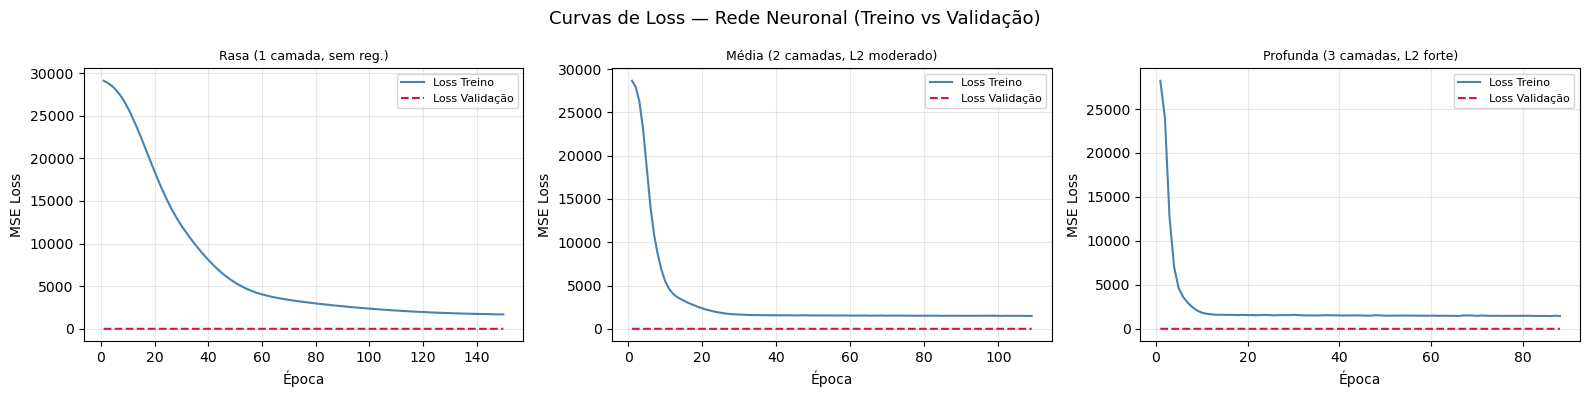

In [ ]:
#TODO: Adicionar configurações, para precisão, fine tuning, cenas
#TODO: Pensar se as layers também deviam ser configuraveis

# Rede neuronal, optimização estruturada
nn_configs = [
    {
        'name':               'Rasa (1 camada, sem reg.)',
        'hidden_layer_sizes': (64,),
        'alpha':              0.0001,
        'learning_rate_init': 0.001,
    },
    {
        'name':               'Média (2 camadas, L2 moderado)',
        'hidden_layer_sizes': (128, 64),
        'alpha':              0.001,
        'learning_rate_init': 0.001,
    },
    {
        'name':               'Profunda (3 camadas, L2 forte)',
        'hidden_layer_sizes': (256, 128, 64),
        'alpha':              0.01,
        'learning_rate_init': 0.001,
    },
]

# Subsample para CV — 15k registos preservam a distribuição e são 4x mais rápidos
sample_idx_cv = np.random.default_rng(42).choice(len(X), size=15000, replace=False)
X_cv = X.iloc[sample_idx_cv]
y_cv = y[sample_idx_cv]

# Subsample separado para curvas de loss
sample_idx_loss = np.random.default_rng(0).choice(len(X), size=5000, replace=False)
X_loss = X.iloc[sample_idx_loss]
y_loss = y[sample_idx_loss]

nn_results  = []
loss_curves = []

for cfg in nn_configs:
    m = MLPRegressor(
        hidden_layer_sizes  = cfg['hidden_layer_sizes'],
        alpha               = cfg['alpha'],
        learning_rate_init  = cfg['learning_rate_init'],
        max_iter            = 150,
        early_stopping      = True,
        validation_fraction = 0.1,
        n_iter_no_change    = 10,
        random_state        = 42,
    )

    res = run_cv(m, X_cv, y_cv, kf)      # CV em 15k
    nn_results.append({**cfg, **res})

    m_full = MLPRegressor(
        hidden_layer_sizes  = cfg['hidden_layer_sizes'],
        alpha               = cfg['alpha'],
        learning_rate_init  = cfg['learning_rate_init'],
        max_iter            = 150,
        early_stopping      = True,
        validation_fraction = 0.1,
        n_iter_no_change    = 10,
        random_state        = 42,
    )
    m_full.fit(X_loss, y_loss)            # curvas de loss em 5k

    loss_curves.append({
        'name':       cfg['name'],
        'train_loss': m_full.loss_curve_,
        'val_loss':   m_full.validation_scores_,
    })

    print(f"\n  {cfg['name']}")
    print(f"\tArquitetura: {cfg['hidden_layer_sizes']}  L2={cfg['alpha']}  lr={cfg['learning_rate_init']}")
    print(f"\tMAE  = {res['mae_mean']:.4f} +/- {res['mae_std']:.4f}")
    print(f"\tRMSE = {res['rmse_mean']:.4f} +/- {res['rmse_std']:.4f}")

best_nn = min(nn_results, key=lambda r: r['mae_mean'])
results_all['NeuralNet'] = best_nn
print(f"\nMelhor configuração NN: {best_nn['name']} (MAE={best_nn['mae_mean']:.4f})")

# Curvas de loss
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Curvas de Loss da Rede Neuronal (Treino vs Validação)', fontsize=13)
for ax, lc in zip(axes, loss_curves):
    epochs     = range(1, len(lc['train_loss']) + 1)
    val_epochs = range(1, len(lc['val_loss']) + 1)
    ax.plot(epochs,     lc['train_loss'],              label='Loss Treino',    color='steelblue')
    ax.plot(val_epochs, [-v for v in lc['val_loss']], label='Loss Validação', color='crimson', linestyle='--')
    ax.set_title(lc['name'], fontsize=9)
    ax.set_xlabel('Época')
    ax.set_ylabel('MSE Loss')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 4.2.4 - Comparação de modelos

In [29]:
rows = [
    [
        name,
        res["mae_mean"],
        res["mae_std"],
        res["rmse_mean"],
        res["rmse_std"],
    ]
    for name, res in results_all.items()
]

print_table(
    headers=["Modelo", "MAE", "+/-", "RMSE", "+/-"],
    rows=rows,
    title="Comparação de Modelos"
)

best_model_name = min(results_all, key=lambda k: results_all[k]["mae_mean"])

print(
    f"\nMelhor modelo: {best_model_name} "
    f"(MAE={results_all[best_model_name]['mae_mean']:.4f})"
)

# Guardar para depois
best_models = sorted(results_all, key=lambda k: results_all[k]["mae_mean"])
print(f"Ranking: {best_models}")


Comparação de Modelos
  Modelo        MAE    +/-    RMSE    +/-
  ───────── ─────── ────── ─────── ──────
  Linear    37.4910 0.2554 57.2960 0.3081
  Tree      36.3321 0.3872 59.3109 0.7100
  SVM       36.7111 0.2478 59.3859 0.2843
  NeuralNet 35.6205 0.8973 56.5366 2.9233

Melhor modelo: NeuralNet (MAE=35.6205)
Ranking: ['NeuralNet', 'Tree', 'SVM', 'Linear']


### 4.2.5 - Curvas de aprendizagem (2 Melhores Modelos)

In [ ]:
#TODO: Mais uma vez, parametros

best_models_reg = sorted(results_all, key=lambda k: results_all[k]['mae_mean'])[:2]
print(f"\n\t2 melhores modelos: {best_models_reg}")

def make_reg_model(name):
    if name == 'Linear':
        return LinearRegression()
    elif name == 'Tree':
        return DecisionTreeRegressor(max_depth=10, random_state=42)
    elif name == 'SVM':
        return LinearSVR(C=best_svm['C'], max_iter=3000, random_state=42)
    elif name == 'NeuralNet':
        return MLPRegressor(
            hidden_layer_sizes  = best_nn['hidden_layer_sizes'],
            alpha               = best_nn['alpha'],
            learning_rate_init  = best_nn['learning_rate_init'],
            max_iter            = 150,
            early_stopping      = True,
            n_iter_no_change    = 10,
            random_state        = 42,
        )

# Subsample para learning_curve ser viável (mantém distribuição)
sample_idx = np.random.default_rng(42).choice(len(X), size=15000, replace=False)
X_lc = X.iloc[sample_idx]
y_lc = y[sample_idx]


	2 melhores modelos: ['NeuralNet', 'Tree']


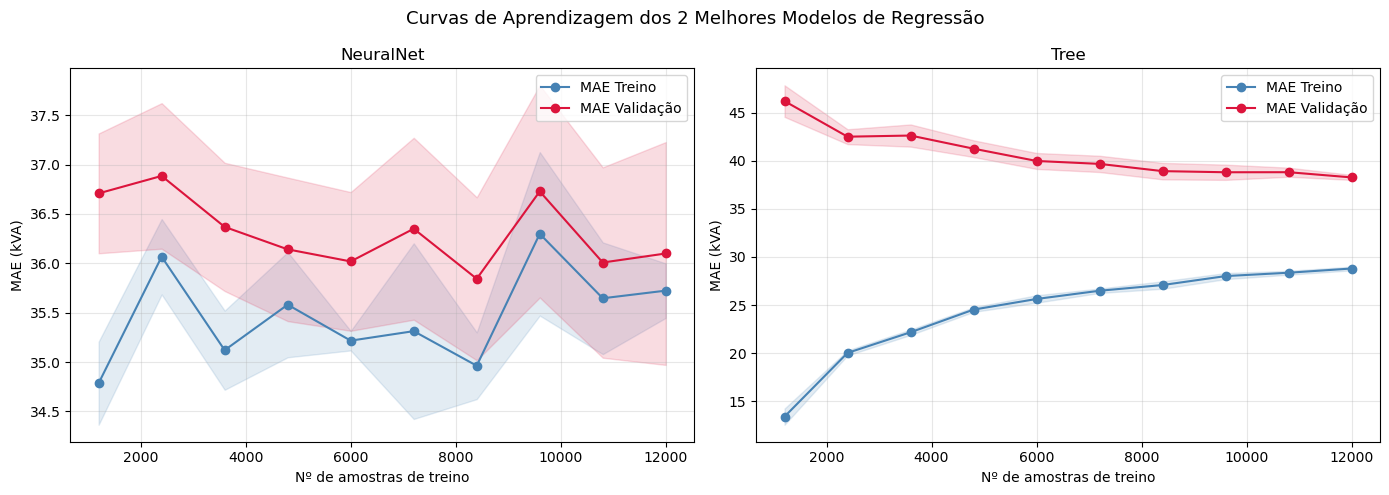

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Curvas de Aprendizagem dos 2 Melhores Modelos de Regressão', fontsize=13)

diagnostics = {}

for idx, model_name in enumerate(best_models_reg):
    model = make_reg_model(model_name)

    train_sizes, train_scores, val_scores = learning_curve(
        model, X_lc, y_lc,
        cv          = 5,
        train_sizes = np.linspace(0.1, 1.0, 10),
        scoring     = 'neg_mean_absolute_error',
        n_jobs      = -1,
    )

    # Converter de negativo para positivo (MAE)
    train_mae = -train_scores
    val_mae   = -val_scores

    train_mean = train_mae.mean(axis=1)
    train_std  = train_mae.std(axis=1)
    val_mean   = val_mae.mean(axis=1)
    val_std    = val_mae.std(axis=1)

    ax = axes[idx]
    ax.plot(train_sizes, train_mean, 'o-', color='steelblue', label='MAE Treino')
    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                    alpha=0.15, color='steelblue')
    ax.plot(train_sizes, val_mean, 'o-', color='crimson', label='MAE Validação')
    ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std,
                    alpha=0.15, color='crimson')
    ax.set_xlabel('Nº de amostras de treino')
    ax.set_ylabel('MAE (kVA)')
    ax.set_title(f'{model_name}')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Diagnóstico automático
    final_train = train_mean[-1]
    final_val   = val_mean[-1]
    gap         = final_val - final_train   # positivo = val pior que treino

    diagnostics[model_name] = {
        'final_train': final_train,
        'final_val':   final_val,
        'gap':         gap,
    }

plt.tight_layout()
plt.show()

In [32]:
# Intepretação automatica

for model_name, d in diagnostics.items():
    print(f"\n  {model_name}:")
    print(f"\tMAE Treino   (final): {d['final_train']:.4f} kVA")
    print(f"\tMAE Validação (final): {d['final_val']:.4f} kVA")
    print(f"\tGap (val - treino):   {d['gap']:.4f} kVA")

    if d['gap'] > 20 and d['final_train'] < 10:
        diagnosis = "⚠️ OVERFITTING — treino muito melhor que validação"
        detail    = "\tO modelo memoriza os dados de treino mas não generaliza."
    elif d['final_val'] > 60:
        diagnosis = "⚠️ UNDERFITTING — erro elevado em treino e validação"
        detail    = "\tO modelo não tem capacidade suficiente para capturar o padrão."
    elif d['gap'] < 10:
        diagnosis = "✓ TREINO ADEQUADO — curvas convergem e gap reduzido"
        detail    = "\tO modelo generaliza bem para dados não vistos."
    else:
        diagnosis = "~ LIGEIRO OVERFITTING — gap moderado, aceitável"
        detail    = "\tConsiderar mais regularização ou menos profundidade."

    print(f"    {diagnosis}")
    print(f"{detail}")

print(f"""
─────────────────────────────────────────────────────────────
NOTA PARA ARTIGO CIENTÍFICO:
As curvas de aprendizagem avaliam se os modelos beneficiariam
de mais dados (curvas ainda a convergir) ou se já estabilizaram.
Um gap persistente entre treino e validação indica overfitting;
curvas altas e paralelas indicam underfitting. A estabilização
das curvas com o aumento de amostras sugere que mais dados não
melhorariam significativamente o desempenho.
─────────────────────────────────────────────────────────────
""")


  NeuralNet:
	MAE Treino   (final): 35.7230 kVA
	MAE Validação (final): 36.0993 kVA
	Gap (val - treino):   0.3763 kVA
    ✓ TREINO ADEQUADO — curvas convergem e gap reduzido
	O modelo generaliza bem para dados não vistos.

  Tree:
	MAE Treino   (final): 28.8033 kVA
	MAE Validação (final): 38.2649 kVA
	Gap (val - treino):   9.4616 kVA
    ✓ TREINO ADEQUADO — curvas convergem e gap reduzido
	O modelo generaliza bem para dados não vistos.

─────────────────────────────────────────────────────────────
NOTA PARA ARTIGO CIENTÍFICO:
As curvas de aprendizagem avaliam se os modelos beneficiariam
de mais dados (curvas ainda a convergir) ou se já estabilizaram.
Um gap persistente entre treino e validação indica overfitting;
curvas altas e paralelas indicam underfitting. A estabilização
das curvas com o aumento de amostras sugere que mais dados não
melhorariam significativamente o desempenho.
─────────────────────────────────────────────────────────────



## 4.3. Classificação

# ?????????????????

## 4.5 - Conclusões e Discussão de Limitações

In [33]:
print("=" * 80)
print("4.5 - CONCLUSÕES, LIMITAÇÕES E SUGESTÕES DE MELHORIA")
print("=" * 80)

print("\n" + "█" * 80)
print("📊 RESUMO DOS RESULTADOS")
print("█" * 80)

print(f"\n1️⃣  REGRESSÃO (Previsão de PFolga_PTD):")
print(f"    ✓ Melhor Modelo: {best_models[0]}")
print(f"    • MAE: {comparison_df[comparison_df['Modelo']==best_models[0]]['MAE (kVA)'].values[0]:.4f} kVA")
print(f"    • RMSE: {comparison_df[comparison_df['Modelo']==best_models[0]]['RMSE (kVA)'].values[0]:.4f} kVA")
print(f"    • Top 3 Features Importantes: {', '.join(feature_importance.head(3)['Feature'].values)}")

print(f"\n2️⃣  CLASSIFICAÇÃO (Previsão de Nível de Ocupação):")
print(f"    ✓ Melhor Modelo: {best_models_clf[0]}")
print(f"    • F1-Score: {comparison_clf_df[comparison_clf_df['Modelo']==best_models_clf[0]]['F1-Score'].values[0]:.4f}")
print(f"    • Accuracy: {comparison_clf_df[comparison_clf_df['Modelo']==best_models_clf[0]]['Accuracy'].values[0]:.4f}")
print(f"    • Top 3 Features Importantes: {', '.join(feature_importance_clf.head(3)['Feature'].values)}")

print("\n" + "⚠️  " + "█" * 77)
print("⚠️  LIMITAÇÕES FUNDAMENTAIS DOS DADOS - LACUNAS CRÍTICAS")
print("⚠️  " + "█" * 77)

print("""
🔴 1. AUSÊNCIA DE DADOS TEMPORAIS:
   O dataset é um snapshot estático sem dimensão temporal (série histórica).
   IMPACTO: Impossível modelar variações sazonais de carga, padrões diários de 
           consumo, ou eventos extraordinários (picos de calor, emergências climáticas).
   MELHORIA: Integrar dados mensais/diários (12+ meses) para captar sazonalidade
            e treinar modelos ARIMA/LSTM para previsão robusta.

🔴 2. FALTA DE DADOS DE CONTEXTO GEOGRÁFICO-SOCIAL:
   Sem informação sobre: densidade populacional, proximidade a centros urbanos,
   presença de indústria, áreas residenciais vs comerciais, ou potencial de 
   adoção de VE (garagens, estacionamentos disponíveis).
   IMPACTO: Correlação baixa entre features disponíveis e viabilidade real de
            carregadores de VE em cada PTD.
   MELHORIA: Incluir features geoespaciais (lat/lon densidade, POI buffer),
            dados demográficos municipais, e levantamentos de infraestrutura.

🔴 3. AUSÊNCIA DE DADOS COMPORTAMENTAIS E ADOÇÃO DE VE:
   Nenhuma informação sobre: procura real de VE, taxa de crescimento de EV,
   padrões de carregamento (doméstico, público, rápido), ou mobilidade esperada
   por zona.
   IMPACTO: Carga VE (PVE) calculada com 22 kW fixo e fator simultaneidade 0.6
            é aproximação muito simplista. Impossível diferenciar viabilidade real
            entre PTDs com contextos diferentes.
   MELHORIA: Incorporar dados de registo de VE por concelho, estudos de mobilidade,
            e cenários de penetração de EV (LOW, MEDIUM, HIGH).

🔴 4. FALTA DE DADOS DE QUALIDADE E CONFIABILIDADE DA REDE:
   Sem informação sobre: tensão de rede, perdas técnicas, distorção harmónica,
   qualidade de energia, ou histórico de falhas/incidentes.
   IMPACTO: Impossível avaliar impacto real de carregadores na estabilidade da rede
            ou necessidade de investimentos em reforço infraestrutural.
   MELHORIA: Integrar dados de qualidade de energia (telemetria SCADA) e histórico
            de perturbações.

🔴 5. PRECISÃO LIMITADA EM VARIÁVEIS AGREGADAS:
   Variáveis como "P_IP_Total" e "LED_Ratio" são agregadas por concelho, não por PTD.
   IMPACTO: Perda de precisão – assumir que todo PTD tem o mesmo perfil que a média
            do concelho é incorreto. Alguns PTDs podem ter 100% LED, outros 0%.
   MELHORIA: Se disponível, obter dados de IP desagregados por PTD ou zona elétrica.

🟡 6. MODELO DE SIMULTANEIDADE MUITO SIMPLIFICADO:
   Carga VE = N_PTDs × 22 kW × 0.6 é demasiado genérica.
   IMPACTO: Não reflecte variabilidade real de carregamento entre PTDs
            (ex: PTD em zona residencial vs comercial tem perfis completamente diferentes).
   MELHORIA: Calibrar fator de simultaneidade por tipo de zona, incluir perfis
            de carga horários, cenários de crescimento.
""")

print("\n" + "💡 " + "█" * 77)
print("💡 RECOMENDAÇÕES PARA EVOLUÇÃO DO MODELO")
print("💡 " + "█" * 77)

print("""
✅ CURTO PRAZO (próximos iterações TP3+):
   1. Incluir dados históricos (mínimo 24 meses) para captar sazonalidade
   2. Desagregar P_IP por PTD ou por zona elétrica menor
   3. Refinar estimativa de Carga_VE com cenários múltiplos (LOW/MED/HIGH)
   4. Adicionar features de qualidade de rede (se disponível)

✅ MÉDIO PRAZO (novos dados):
   1. Incorporar dados geoespaciais (OSM, densidade populacional)
   2. Integrar estudo de mobilidade elétrica por zona
   3. Incluir histórico de adoção de VE e tendências
   4. Coletar dados de confiabilidade de rede (SAIDI, SAIFI)

✅ LONGO PRAZO (transformação digital):
   1. Implementar telemetria em tempo real para todos os PTDs
   2. Criar modelo de simulação de rede (powerflow) integrado
   3. Desenvolver plataforma de previsão com atualização automática
   4. Permitir simulação de cenários (clima, mobilidade, políticas)
""")

print("\n✓ Conclusão: Os modelos desenvolvidos explicam a viabilidade de VE ao nível")
print("  da rede de PTD, mas a precisão é limitada pela disponibilidade de dados.")
print("  Recomenda-se fortemente a evolução do dataset conforme indicado acima")
print("  antes de decisões de investimento crítico em infraestrutura de VE.")

4.5 - CONCLUSÕES, LIMITAÇÕES E SUGESTÕES DE MELHORIA

████████████████████████████████████████████████████████████████████████████████
📊 RESUMO DOS RESULTADOS
████████████████████████████████████████████████████████████████████████████████

1️⃣  REGRESSÃO (Previsão de PFolga_PTD):
    ✓ Melhor Modelo: NeuralNet


NameError: name 'comparison_df' is not defined